# Ноутбук по обучению модели и оценке качества

In [1]:
import sys

from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import config

In [2]:
from init_pipeline import init_experiment
init_experiment(project_root, config)

Инициализация пропущена: /Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/artifacts/boosting_pipeline/status.json уже существует и init=True


## Логирование

In [3]:
import os

from src.utils.logger import setup_logging

LOG_DIR = project_root / 'artifacts' / config.general.experiment_name / 'log'
os.makedirs(LOG_DIR, exist_ok=True)

LOG_FILE = LOG_DIR / 'fit_model.txt'

_logger = setup_logging(LOG_FILE, 'fit_model')

/Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Импорты

In [4]:
# ждем пока выполнится предыдущий ноутбук
import json
import time

while True:
    with open(project_root / 'artifacts' / config.general.experiment_name / 'status.json', 'r') as f:
        status = json.load(f)
    if status['optimization']:
        _logger.info('Параметры подобраны, обучаем модель')
        break
    time.sleep(60) 

[2026-09-07 18:24:02,364] - [fit_model] - [INFO] - Параметры подобраны, обучаем модель


In [40]:
import shutil
import copy
import json
import random
import time
from functools import partial

import joblib

from IPython.display import clear_output, display

import pandas as pd
import numpy as np

import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, TimeSeriesSplit

from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn.metrics import roc_auc_score, classification_report

from category_encoders import TargetEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklift.models import SoloModel, TwoModels
from causalml.inference.meta import BaseXClassifier
from causalml.propensity import compute_propensity_score

from sklift.metrics import qini_auc_score, uplift_at_k

import pyspark.sql.functions as F
from pyspark.sql.window import Window

import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
from src.preprocessing import preprocess_sdf
from src.utils.uplift_clf_metrics import show_results, evaluate_uplift_with_bootstrap, check_stat_sig_first_bin
from src.utils.feature_stability import calculate_psi

In [7]:
if config.general.load_venv_to_spark:
    os.environ['PYSPARK_PYTHON'] = './environment/bin/python'
    os.environ['PYSPARK_DRIVER_PYTHON'] = './environment/bin/python'

In [8]:
np.random.seed(config.general.seed)
random.seed(config.general.seed)

In [9]:
from src.utils.get_spark import get_conf, get_spark

conf = get_conf()

if config.general.load_venv_to_spark:
    conf.set('spark.archives', project_root / 'venv.tar.gz#environment')

In [10]:
spark = get_spark(conf, app_name=config.general.spark_session_name)

clear_output()
spark

## Константы

In [11]:
_logger.info(f"Experiment name: {config.general.experiment_name}")
data_dir = project_root / 'data'
fs_path = project_root / 'artifacts' / config.general.experiment_name / 'feature_selection'
choose_model_path = project_root / 'artifacts' / config.general.experiment_name / 'choose_model'
optimize_path = project_root / 'artifacts' / config.general.experiment_name / 'optimize'
models_path = project_root / 'artifacts' / config.general.experiment_name / 'models'
img_path = project_root / 'artifacts' / config.general.experiment_name / 'img'

os.makedirs(models_path, exist_ok=True)
os.makedirs(img_path, exist_ok=True)

[2026-09-07 18:24:19,809] - [fit_model] - [INFO] - Experiment name: boosting_pipeline


In [12]:
if config.general.optimize:
    with open(fs_path / 'features_selected_final.json', 'r') as f:
        features = json.load(f)
    _logger.info(f'Признаки загружены: {len(features)}')

    with open(choose_model_path / 'choosen_model.json', 'r') as f:
        choosen_model = json.load(f)

    _logger.info(f'Choosen model is {choosen_model}')

[2026-09-07 18:24:19,812] - [fit_model] - [INFO] - Признаки загружены: 25
[2026-09-07 18:24:19,813] - [fit_model] - [INFO] - Choosen model is slearner


## Загрузка и предобработка данных

In [13]:
if config.general.fit_model or config.general.evaluate:
    features_to_select = []
    for feature in features:
        if feature.endswith('_diff'):
            features_to_select.append(feature.replace('_diff', ''))
            continue
        if feature.endswith('_sum'):
            features_to_select.append(feature.replace('_sum', ''))
            continue
        features_to_select.append(feature)

In [14]:
if config.general.fit_model or config.general.evaluate:
    _logger.info('Загружаем датасет')
    train_dataset = spark.read.parquet(str(data_dir / 'train_dataset.parquet'))
    train_dataset = train_dataset.select(features_to_select + [config.dataset.date_col, config.dataset.treatment_col, config.dataset.target_col])

    len_train_dataset = train_dataset.count()
    _logger.info(f'Train dataset length: {len_train_dataset}, dataset columns: {len(train_dataset.columns)}')

    train_dataset, dt_features, bitmask_cols = preprocess_sdf(train_dataset, config)
    train_dataset = train_dataset.select(features+[config.dataset.date_col, config.dataset.treatment_col, config.dataset.target_col])

    def find_string_features(sdf):
        def find_str(pair):
            col, dtype = pair
            if col not in [config.dataset.date_col, config.dataset.target_col, config.dataset.treatment_col]:
                if dtype == 'string':
                    return col
        return [pair[0] for pair in list(filter(find_str, sdf.dtypes))]

    string_features = find_string_features(train_dataset)
    string_cols_to_encode = [col for col in features if col in string_features]
    _logger.info(f"Строковых признаков: {len(string_cols_to_encode)}")

    train_dataset = train_dataset.toPandas()

    # oos
    oos_dataset = spark.read.parquet(str(data_dir / 'oos_dataset.parquet'))
    oos_dataset = oos_dataset.select(features_to_select + [config.dataset.date_col, config.dataset.treatment_col, config.dataset.target_col])

    oos_dataset, _, _ = preprocess_sdf(oos_dataset, config)
    oos_dataset = oos_dataset.select(features+[config.dataset.date_col, config.dataset.treatment_col, config.dataset.target_col])

    len_oos_dataset = oos_dataset.count()
    _logger.info(f'OOS dataset length: {len_oos_dataset}')

    oos_dataset = oos_dataset.toPandas()

    # oot
    oot_dataset = spark.read.parquet(str(data_dir / 'oot_dataset.parquet'))
    oot_dataset = oot_dataset.select(features_to_select + [config.dataset.date_col, config.dataset.treatment_col, config.dataset.target_col])

    oot_dataset, _, _ = preprocess_sdf(oot_dataset, config)
    oot_dataset = oot_dataset.select(features+[config.dataset.date_col, config.dataset.treatment_col, config.dataset.target_col])

    len_oot_dataset = oot_dataset.count()
    _logger.info(f'OOT dataset length: {len_oot_dataset}')

    oot_dataset = oot_dataset.toPandas()

[2026-09-07 18:24:19,820] - [fit_model] - [INFO] - Загружаем датасет


[2026-09-07 18:24:21,968] - [fit_model] - [INFO] - Train dataset length: 458976, dataset columns: 28
[2026-09-07 18:24:21,969] - [src.preprocessing] - [INFO] - Num of datetime features: 0
[2026-09-07 18:24:21,969] - [src.preprocessing] - [INFO] - Num of bitmask features: 0
[2026-09-07 18:24:22,014] - [src.preprocessing] - [INFO] - Num of decimal features: 0
[2026-09-07 18:24:22,015] - [src.preprocessing] - [INFO] - Unique datatypes in dataset: {'int', 'double', 'string'}
[2026-09-07 18:24:22,042] - [fit_model] - [INFO] - Строковых признаков: 0


26/09/07 18:24:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

[2026-09-07 18:24:26,738] - [src.preprocessing] - [INFO] - Num of datetime features: 0
[2026-09-07 18:24:26,738] - [src.preprocessing] - [INFO] - Num of bitmask features: 0
[2026-09-07 18:24:26,760] - [src.preprocessing] - [INFO] - Num of decimal features: 0
[2026-09-07 18:24:26,761] - [src.preprocessing] - [INFO] - Unique datatypes in dataset: {'int', 'double', 'string'}
[2026-09-07 18:24:26,850] - [fit_model] - [INFO] - OOS dataset length: 81026
[2026-09-07 18:24:27,642] - [src.preprocessing] - [INFO] - Num of datetime features: 0
[2026-09-07 18:24:27,643] - [src.preprocessing] - [INFO] - Num of bitmask features: 0
[2026-09-07 18:24:27,659] - [src.preprocessing] - [INFO] - Num of decimal features: 0
[2026-09-07 18:24:27,660] - [src.preprocessing] - [INFO] - Unique datatypes in dataset: {'int', 'double', 'string'}
[2026-09-07 18:24:27,730] - [fit_model] - [INFO] - OOT dataset length: 59998


In [15]:
if config.general.fit_model or config.general.evaluate:
    X_train, y_train = train_dataset[features+[config.dataset.treatment_col]].copy(), train_dataset[config.dataset.target_col].copy()
    X_oos, y_oos = oos_dataset[features+[config.dataset.treatment_col]].copy(), oos_dataset[config.dataset.target_col].copy()
    X_oot, y_oot = oot_dataset[features+[config.dataset.treatment_col]].copy(), oot_dataset[config.dataset.target_col].copy()

## Обучение модели

In [18]:
if config.general.fit_model:
    _logger.info(f'Обучаем {choosen_model}')

    if len(string_cols_to_encode):
        _logger.info(f'There are {len(string_cols_to_encode)} string features, fitting encoder')
        encoder = TargetEncoder()
        X_train.loc[:, string_cols_to_encode] = encoder.fit_transform(X_train[string_cols_to_encode], y=y_train)

        joblib.dump(encoder, models_path / 'encoder.pkl')

    if choosen_model == 'slearner':
        params = joblib.load(optimize_path / f'{config.optimization.metric_to_optimize.value}_best_params.pkl')
        _logger.info(f'Params loaded:\n{params}')

        model = SoloModel(estimator=CatBoostClassifier(**params))
        model.fit(X_train[features], y_train, X_train[config.dataset.treatment_col])

    if choosen_model == 'tlearner':
        params_tr = joblib.load(optimize_path / f'{config.optimization.metric_to_optimize.value}_best_params_tr.pkl')
        params_c = joblib.load(optimize_path / f'{config.optimization.metric_to_optimize.value}_best_params_c.pkl')
        _logger.info(f'Params loaded:\nParams TR:\n{params_tr}\nParams C:\n{params_c}')

        model = TwoModels(
            estimator_trmnt=CatBoostClassifier(**params_tr),
            estimator_ctrl=CatBoostClassifier(**params_c)
        )
        model.fit(x_train[features], y_train, x_train[config.dataset.treatment_col])

    if choosen_model == 'xlearner':
        params_co = joblib.load(optimize_path / f'{config.optimization.metric_to_optimize.value}_best_params_co.pkl')
        params_to = joblib.load(optimize_path / f'{config.optimization.metric_to_optimize.value}_best_params_to.pkl')
        params_ce = joblib.load(optimize_path / f'{config.optimization.metric_to_optimize.value}_best_params_ce.pkl')
        params_te = joblib.load(optimize_path / f'{config.optimization.metric_to_optimize.value}_best_params_te.pkl')
        _logger.info(f'Params loaded:\nParams CO:\n{params_co}\nParams TO:\n{params_to}\nParams CE:\n{params_ce}\nParams TE:\n{params_te}')

        p, propensity_model = compute_propensity_score(
            X_train[features].values,
            X_train[config.dataset.treatment_col].values,
            calibrate_p=False
        )
        joblib.dump(propensity_model, models_path / 'propensity_model.pkl')

        model = BaseXClassifier(
            control_outcome_learner=CatBoostClassifier(**params_co),
            treatment_outcome_learner=CatBoostClassifier(**params_to),
            control_effect_learner=CatBoostRegressor(**params_ce),
            treatment_effect_learner=CatBoostRegressor(**params_te)
        )

        model.fit(X=x_train[features].values, treatment=x_train[config.dataset.treatment_col], y=y_train.ravel(), p=p)

    joblib.dump(model, models_path / 'model.pkl')
    _logger.info(f"Model saved to {models_path / 'model.pkl'}")

[2026-09-07 18:25:21,295] - [fit_model] - [INFO] - Model saved to /Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/artifacts/boosting_pipeline/models/model.pkl


## Проверка качества полученной модели

In [19]:
if config.general.evaluate:
    if len(string_cols_to_encode):
        encoder = joblib.load(models_path / 'encoder.pkl')

    model = joblib.load(models_path / 'model.pkl')
    if choosen_model == 'xlearner':
        propensity_model = joblib.load(models_path / 'propensity_model.pkl')
    _logger.info("Обученная модель загружена")

[2026-09-07 18:25:34,331] - [fit_model] - [INFO] - Обученная модель загружена


## Важность признаков

In [20]:
if config.general.evaluate:
    _logger.info(f"Сохраним важности признаков в {fs_path}")

    if choosen_model == 'slearner':
        f_i = model.estimator.get_feature_importance(prettified=True)
        f_i.to_csv(fs_path / 'feature_importance.csv', index=False)
        
    if choosen_model == 'tlearner':
        f_i_tr = model.estimator_trmnt.get_feature_importance(prettified=True)
        f_i_tr = model.estimator_ctrl.get_feature_importance(prettified=True)
        
        f_i_tr.to_csv(fs_path / 'feature_importance_tr.csv', index=False)
        f_i_c.to_csv(fs_path / 'feature_importance_c.csv', index=False)

    if choosen_model == 'xlearner':
        f_i_mu_c = model.models_mu_c[1].get_feature_importance(prettified=True)
        f_i_mu_c['Feature Id'] = np.array(features)[f_i_mu_c['Feature Id'].values.astype(int)]

        f_i_mu_t = model.models_mu_t[1].get_feature_importance(prettified=True)
        f_i_mu_t['Feature Id'] = np.array(features)[f_i_mu_t['Feature Id'].values.astype(int)]
        
        f_i_mu_c.to_csv(fs_path / 'feature_importance_mu_c.csv', index=False)
        f_i_mu_t.to_csv(fs_path / 'feature_importance_mu_t.csv', index=False)

[2026-09-07 18:25:35,890] - [fit_model] - [INFO] - Сохраним важности признаков в /Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/artifacts/boosting_pipeline/feature_selection


## Качество train

In [21]:
if config.general.evaluate and len(string_cols_to_encode) and not config.general.fit_model:
    X_train.loc[:, string_cols_to_encode] = encoder.transform(X_train[string_cols_to_encode])

In [22]:
if config.general.evaluate:
    if choosen_model == 'xlearner':
        uplift_train = model.predict(X_train[features].values, p=propensity_model.predict(X_train[features])).ravel()
    elif choosen_model in ['slearner', 'tlearner']:
        uplift_train = model.predict(X_train[features]).ravel()

In [23]:
if config.general.evaluate:
    show_results(
        y_train.values,
        uplift_train,
        X_train[config.dataset.treatment_col].values,
        save=True,
        save_path=img_path,
        save_prefix=f'{config.optimization.metric_to_optimize.value}_train'
    )

[2026-09-07 18:25:42,729] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-07 18:25:42,732] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-07 18:25:42,769] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-07 18:25:42,774] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotti

<Figure size 800x2125 with 5 Axes>

In [24]:
if config.general.evaluate:
    _logger.info('Стат. значимость uplift в первом бине')
    _logger.info(check_stat_sig_first_bin(y_train.values, uplift_train, X_train[config.dataset.treatment_col].values, n_bins=5))

[2026-09-07 18:25:48,417] - [fit_model] - [INFO] - Стат. значимость uplift в первом бине
[2026-09-07 18:25:48,529] - [fit_model] - [INFO] - TtestResult(statistic=107.43800638585911, pvalue=0.0, df=91793.0)


Запуск bootstrap (500 итераций)...


100%|█████████████████████████████████████████| 500/500 [02:42<00:00,  3.07it/s]


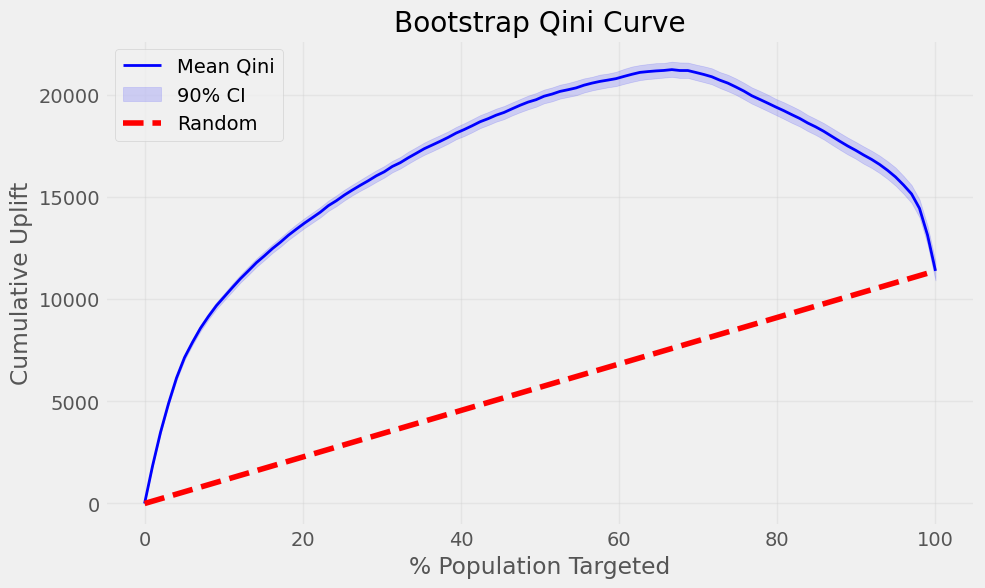


=== Uplift Metrics (Bootstrap 90% CI) ===
            CI_Lower_5%  Mean_Value  CI_Upper_95%
AUQC           0.255050    0.257902      0.260869
Uplift@5%      0.608105    0.617133      0.626889
Uplift@10%     0.433606    0.440493      0.447314
Uplift@30%     0.231178    0.235199      0.239122


In [25]:
if config.general.evaluate:
    train_ci_metrics = evaluate_uplift_with_bootstrap(
        y_train.values,
        uplift_train,
        X_train[config.dataset.treatment_col].values,
        save=True,
        save_path=img_path,
        save_prefix=f'{config.optimization.metric_to_optimize.value}_train'
    )
    train_ci_metrics.to_csv(img_path / f'train_ci_metrics_{config.optimization.metric_to_optimize.value}.csv')

## Качество OOS

In [26]:
if config.general.evaluate and len(string_cols_to_encode):
    X_oos.loc[:, string_cols_to_encode] = encoder.transform(X_oos[string_cols_to_encode])

In [27]:
if config.general.evaluate:
    if choosen_model == 'xlearner':
        uplift_oos = model.predict(X_oos[features].values, p=propensity_model.predict(X_oos[features])).ravel()
    elif choosen_model in ['slearner', 'tlearner']:
        uplift_oos = model.predict(X_oos[features]).ravel()

[2026-09-07 18:28:36,444] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-07 18:28:36,446] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-07 18:28:36,480] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-07 18:28:36,481] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotti

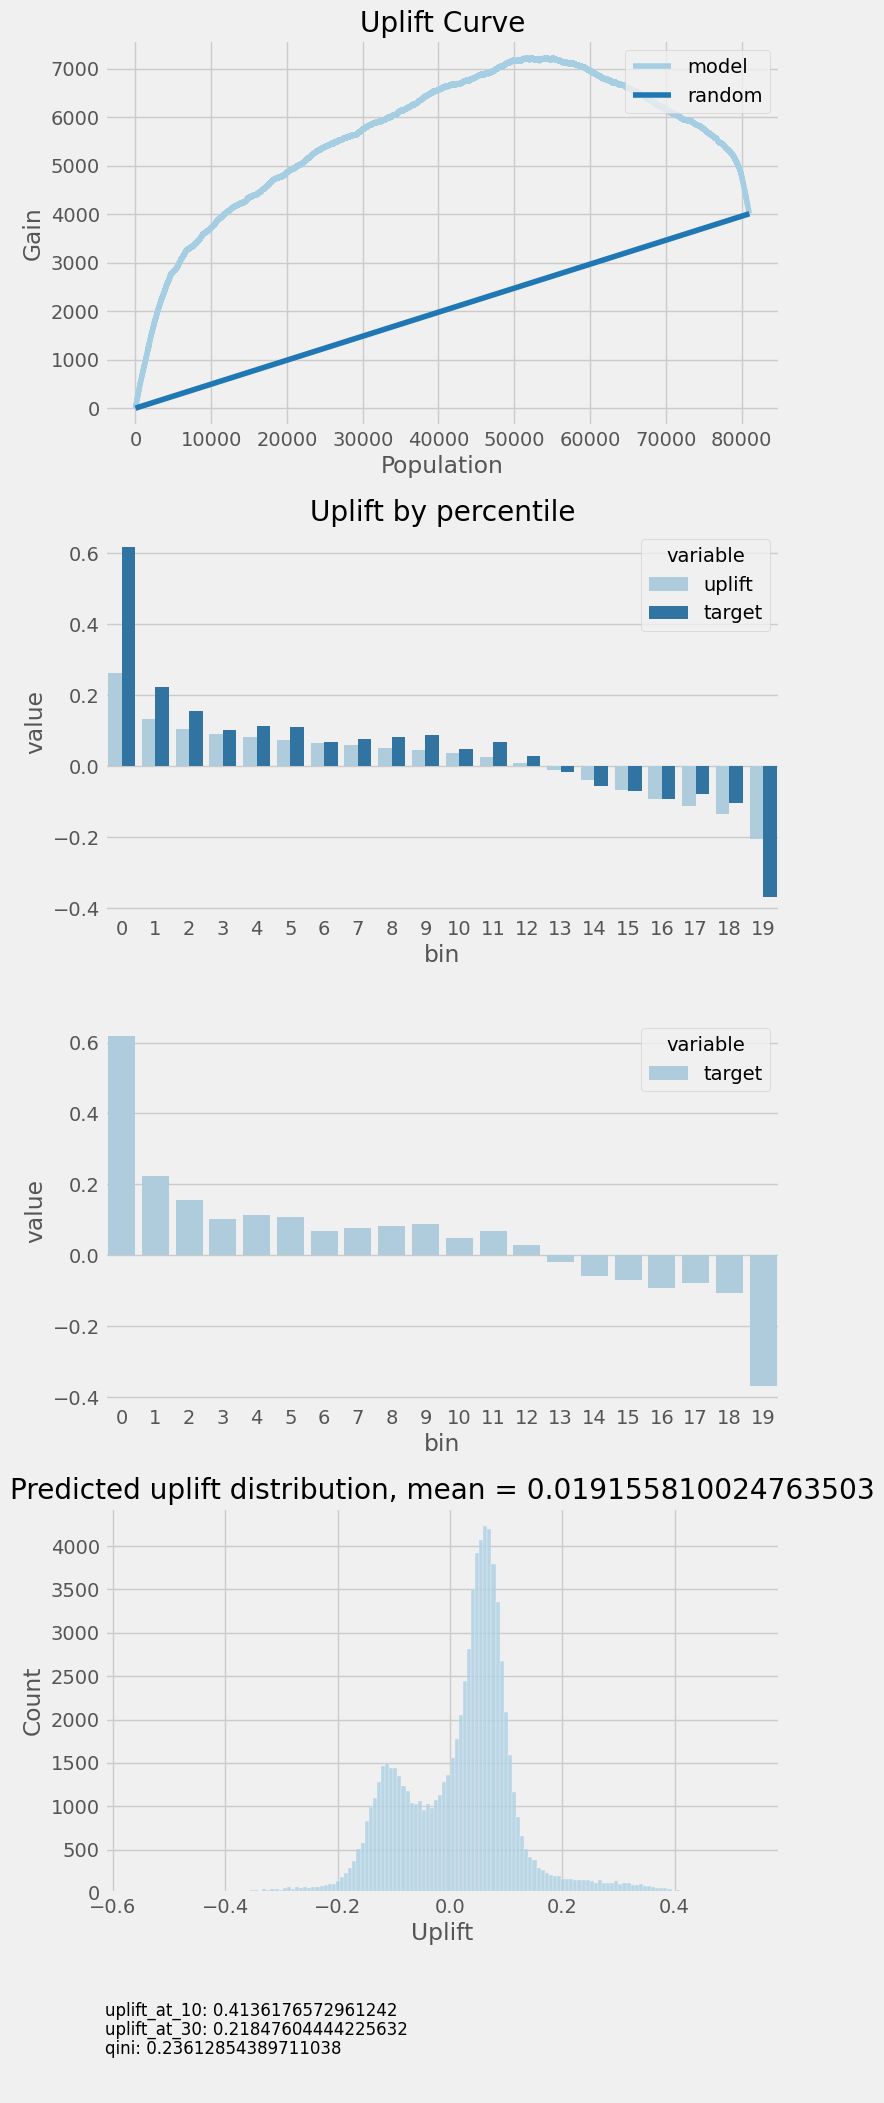

In [28]:
if config.general.evaluate:
    show_results(
        y_oos.values,
        uplift_oos,
        X_oos[config.dataset.treatment_col].values,
        save=True,
        save_path=img_path,
        save_prefix=f'{config.optimization.metric_to_optimize.value}_oos'
    )

In [29]:
if config.general.evaluate:
    _logger.info('Стат. значимость uplift в первом бине')
    _logger.info(check_stat_sig_first_bin(y_oos.values, uplift_oos, X_oos[config.dataset.treatment_col].values, n_bins=5))

[2026-09-07 18:28:37,381] - [fit_model] - [INFO] - Стат. значимость uplift в первом бине
[2026-09-07 18:28:37,394] - [fit_model] - [INFO] - TtestResult(statistic=41.611964479576784, pvalue=0.0, df=16203.0)


Запуск bootstrap (500 итераций)...


100%|█████████████████████████████████████████| 500/500 [00:25<00:00, 19.93it/s]


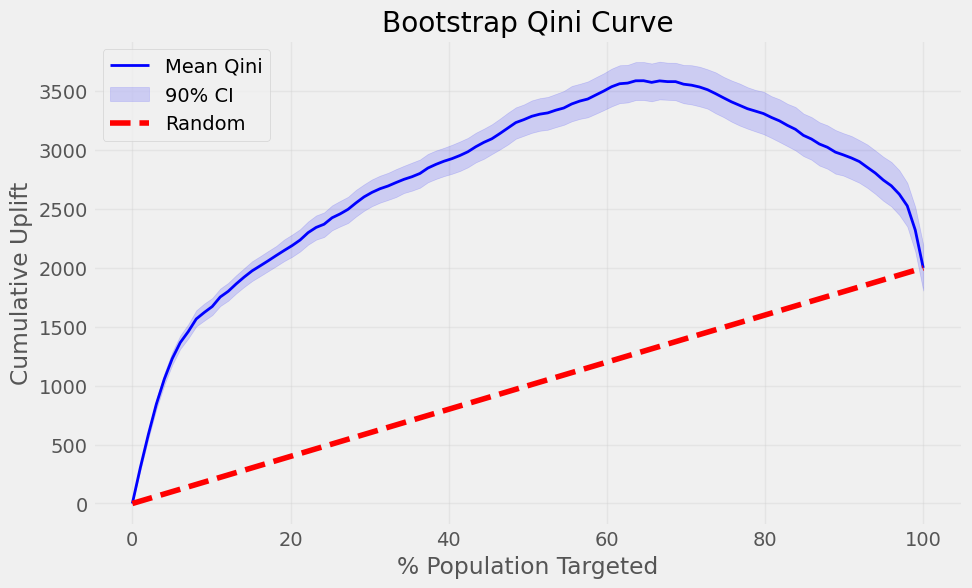


=== Uplift Metrics (Bootstrap 90% CI) ===
            CI_Lower_5%  Mean_Value  CI_Upper_95%
AUQC           0.228978    0.235908      0.242379
Uplift@5%      0.594952    0.615168      0.636942
Uplift@10%     0.395946    0.413652      0.431227
Uplift@30%     0.208583    0.217851      0.226964


In [30]:
if config.general.evaluate:
    oos_ci_metrics = evaluate_uplift_with_bootstrap(
        y_oos.values,
        uplift_oos,
        X_oos[config.dataset.treatment_col].values,
        save=True,
        save_path=img_path,
        save_prefix=f'{config.optimization.metric_to_optimize.value}_oos'
    )
    oos_ci_metrics.to_csv(img_path / f'oos_ci_metrics_{config.optimization.metric_to_optimize.value}.csv')

## Качество OOT

In [31]:
if config.general.evaluate and len(string_cols_to_encode):
    X_oot.loc[:, string_cols_to_encode] = encoder.transform(X_oot[string_cols_to_encode])

In [32]:
if config.general.evaluate:
    if choosen_model == 'xlearner':
        uplift_oot = model.predict(X_oot[features].values, p=propensity_model.predict(X_oot[features])).ravel()
    elif choosen_model in ['slearner', 'tlearner']:
        uplift_oot = model.predict(X_oot[features]).ravel()

[2026-09-07 18:29:02,801] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-07 18:29:02,802] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-07 18:29:02,835] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-07 18:29:02,837] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotti

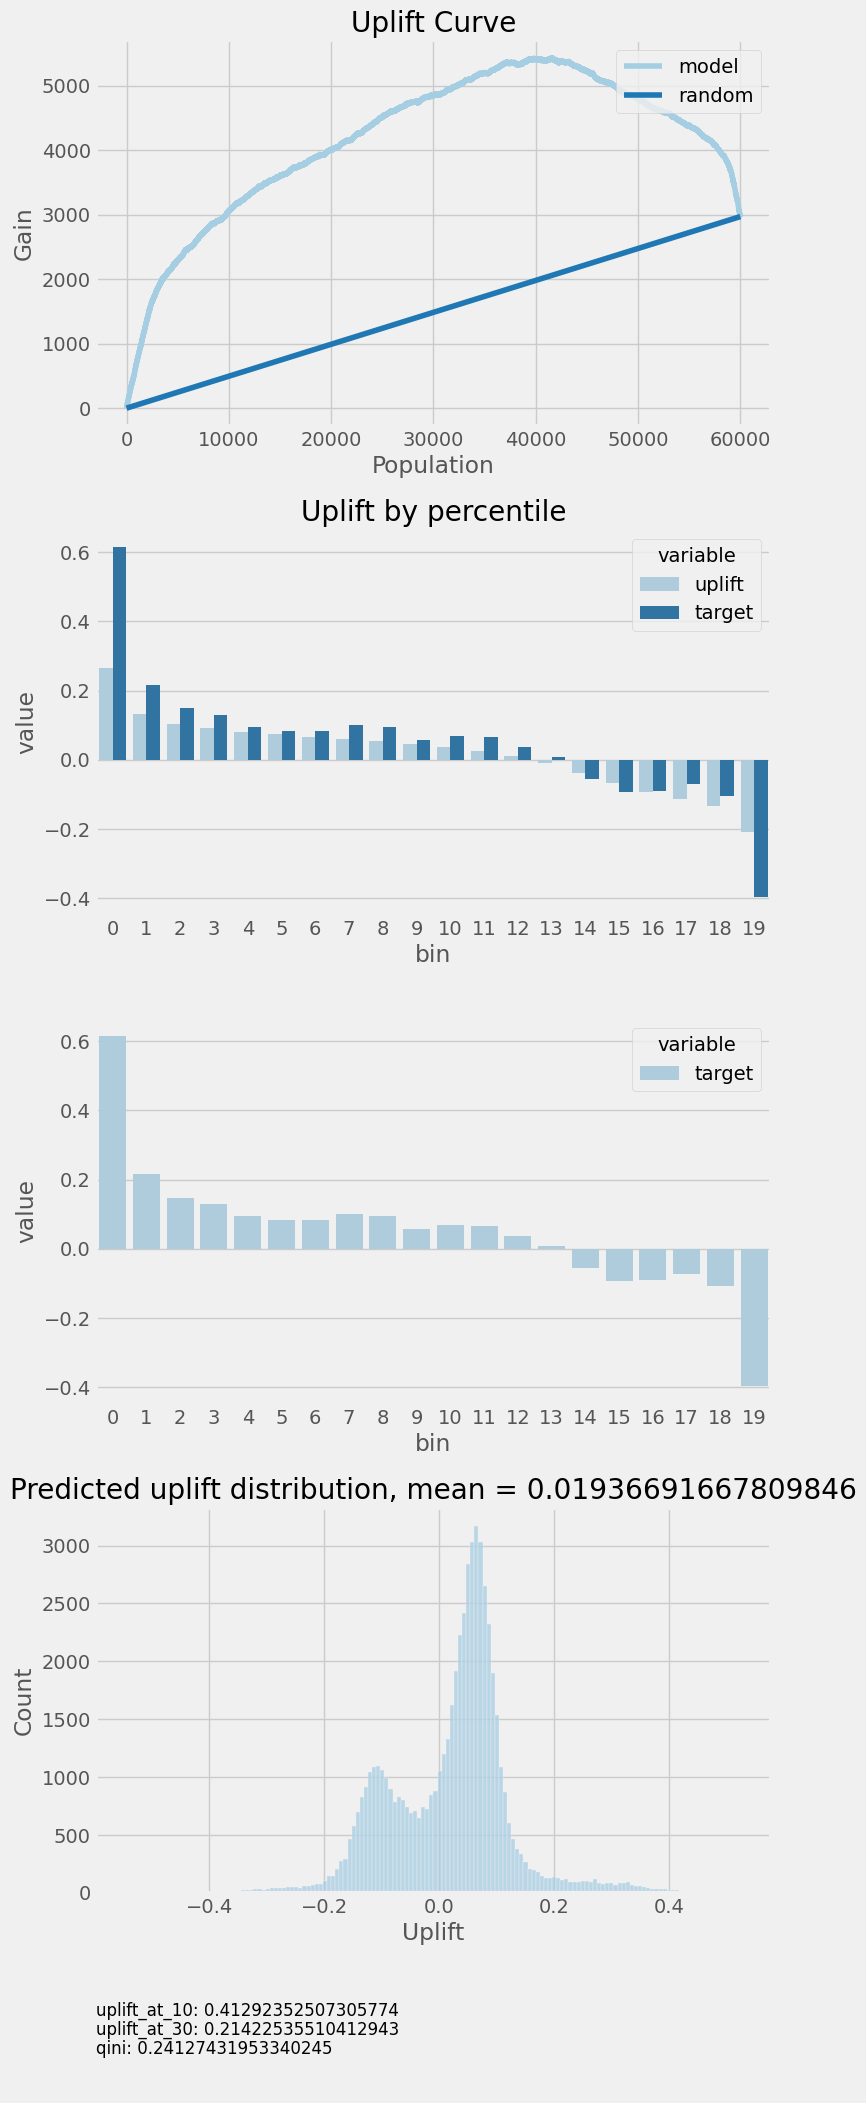

In [33]:
if config.general.evaluate:
    show_results(
        y_oot.values,
        uplift_oot,
        X_oot[config.dataset.treatment_col].values,
        save=True,
        save_path=img_path,
        save_prefix=f'{config.optimization.metric_to_optimize.value}_oot'
    )

In [34]:
if config.general.evaluate:
    _logger.info('Стат. значимость uplift в первом бине')
    _logger.info(check_stat_sig_first_bin(y_oot.values, uplift_oot, X_oot[config.dataset.treatment_col].values, n_bins=5))

[2026-09-07 18:29:03,671] - [fit_model] - [INFO] - Стат. значимость uplift в первом бине
[2026-09-07 18:29:03,681] - [fit_model] - [INFO] - TtestResult(statistic=35.77734086754903, pvalue=1.851931078223344e-266, df=11998.0)


Запуск bootstrap (500 итераций)...


100%|█████████████████████████████████████████| 500/500 [00:18<00:00, 26.85it/s]


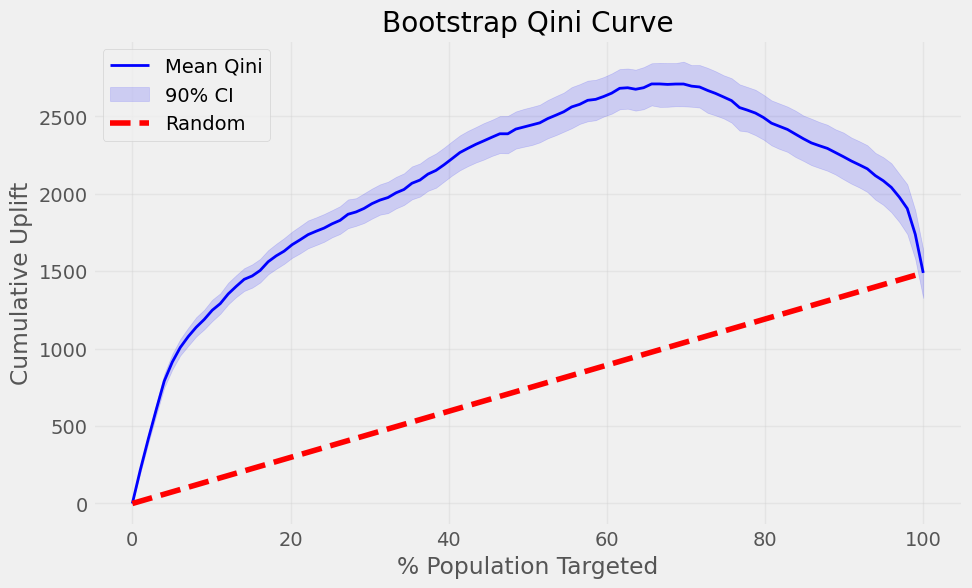


=== Uplift Metrics (Bootstrap 90% CI) ===
            CI_Lower_5%  Mean_Value  CI_Upper_95%
AUQC           0.231637    0.240985      0.249956
Uplift@5%      0.585880    0.611331      0.635404
Uplift@10%     0.392030    0.413093      0.433191
Uplift@30%     0.203513    0.213822      0.224126


In [35]:
if config.general.evaluate:
    oot_ci_metrics = evaluate_uplift_with_bootstrap(
        y_oot.values,
        uplift_oot,
        X_oot[config.dataset.treatment_col].values,
        save=True,
        save_path=img_path,
        save_prefix=f'{config.optimization.metric_to_optimize.value}_oot'
    )
    oot_ci_metrics.to_csv(img_path / f'oot_ci_metrics_{config.optimization.metric_to_optimize.value}.csv')

## Model Explainer

In [38]:
if config.general.evaluate:
    if choosen_model == 'slearner':
        estimator = model.estimator
    elif choosen_model == 'tlearner':
        estimator = model.estimator_trmnt
    elif choosen_model == 'xlearner':
        estimator = model.models_mu_t[1]

    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer(X_oot[features].assign(**{config.dataset.treatment_col: X_oot[config.dataset.treatment_col]}))

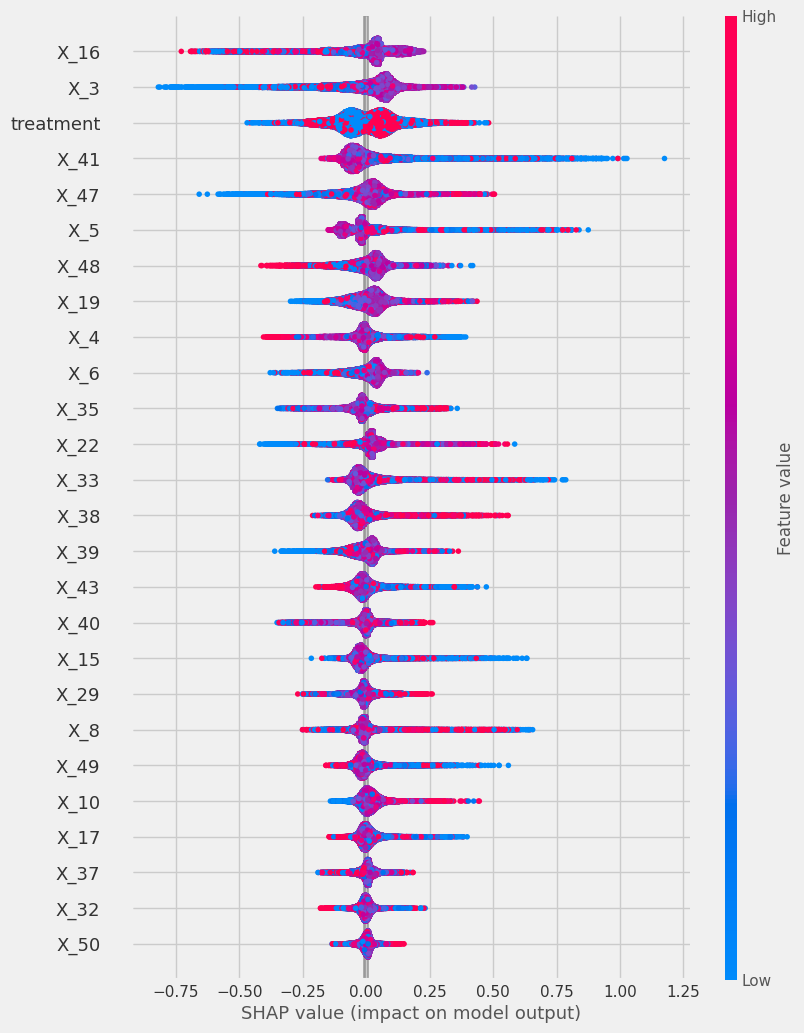

In [41]:
if config.general.evaluate:
    shap.plots.beeswarm(shap_values, max_display=len(features)+1, show=False)
    plt.savefig(img_path / 'shap_fi_oot.png', dpi=300, bbox_inches='tight')
    plt.show()

In [42]:
if config.general.evaluate:
    is_multiclass = False
    s_v = shap_values.values

    if isinstance(s_v, list):
        if is_multiclass:
            importances = []
            for cls_ in s_v:
                c_sum = np.abs(cls_).mean(0)
                importances.append(c_sum.reshape(1, -1))
            importances = np.concatenate(importances).mean(0)
        else:
            importances = np.abs(s_v[1]).mean(0)
    else:
        importances = np.abs(s_v).mean(0)

    f_i_shap = pd.DataFrame({'name': features+[config.dataset.treatment_col], 'importance': importances}).sort_values('importance', ascending=False)
    display(f_i_shap.head())

    f_i_shap.to_csv(fs_path / 'feature_importance_shap.csv', index=False)

,name,importance
18,X_16,0.096739
19,X_3,0.094233
25,treatment,0.086467
17,X_41,0.075003
10,X_47,0.064916


In [43]:
if config.general.evaluate:
    _logger.info('Calculating PSI')

    train_oos_psi = calculate_psi(X_train[features], X_oos[features])
    train_oos_psi['is_unstable'] = 0
    train_oos_psi.loc[train_oos_psi['psi'] >= 0.25, 'is_unstable'] = 2
    train_oos_psi.loc[(train_oos_psi['psi'] >= 0.1) & (train_oos_psi['psi'] < 0.25), 'is_unstable'] = 1

    train_oot_psi = calculate_psi(X_train[features], X_oot[features])
    train_oot_psi['is_unstable'] = 0
    train_oot_psi.loc[train_oot_psi['psi'] >= 0.25, 'is_unstable'] = 2
    train_oot_psi.loc[(train_oot_psi['psi'] >= 0.1) & (train_oot_psi['psi'] < 0.25), 'is_unstable'] = 1

[2026-09-07 18:31:43,821] - [fit_model] - [INFO] - Calculating PSI


In [44]:
if config.general.evaluate:
    def style_rows(row):
        soft_green = '#7cfc00'
        soft_yellow = '#ffcf48'
        soft_red = '#e32636'

        color_map = {0: soft_green, 1: soft_yellow, 2: soft_red}
        color = color_map.get(row['is_unstable'], '')
        return [f'background-color: {color}' for _ in row]

    styled_train_oos_psi = train_oos_psi.style.apply(style_rows, axis=1)
    styled_train_oos_psi.to_html(fs_path / 'train_oos_psi.html')

    styled_train_oot_psi = train_oot_psi.style.apply(style_rows, axis=1)
    styled_train_oot_psi.to_html(fs_path / 'train_oot_psi.html')

    _logger.info(f"PSI по признакам сохранены в {fs_path / 'train_oos_psi.html'} и {fs_path / 'train_oot_psi.html'} ")

[2026-09-07 18:31:46,089] - [fit_model] - [INFO] - PSI по признакам сохранены в /Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/artifacts/boosting_pipeline/feature_selection/train_oos_psi.html и /Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/artifacts/boosting_pipeline/feature_selection/train_oot_psi.html 


In [45]:
with open(project_root / 'artifacts' / config.general.experiment_name / 'status.json', 'w') as f:
    status = {
        'init': True,
        'dataset': True,
        'features': True,
        'choose_model': True,
        'optimization': True,
        'fitting': True
    }
    json.dump(status, f)

In [ ]:
os._exit(00)